# Directed Evolution loop — V1

First simple test of `sequence_classesV1.py` (`Protocol`, `Lambda`) and `analysisV1.py`
(the 8 plotting/analysis functions), on a small toy library.

Pipeline for one round of `Protocol.loop_DE()`:

$$
\lambda_0 \xrightarrow{\text{NGS}} \lambda_0' \qquad
\lambda_0 \xrightarrow{\text{sampling}} \lambda_1 \xrightarrow{\text{produce\_capsids}} \lambda_2 \xrightarrow{\text{NGS}} \lambda_2' \qquad
\lambda_2 \xrightarrow{\text{selectivty}} \lambda_3 \xrightarrow{\text{NGS}} \lambda_3' \qquad
\lambda_3 \xrightarrow{\text{bacterial\_amplification}} \lambda_4
$$

`lambda0/1/2/3/4` = true pools (biological chain). `lambda0p/2p/3p` = NGS read-count
snapshots (side channel, Negative Binomial, never fed back into the chain).


## 0. Protocol parameters

Fixed constants from `sequence_classesV1.py`, used as defaults throughout `Protocol` unless overridden at construction time.

In [2]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# GB10 has unified CPU/GPU memory: JAX's default (preallocate ~75% of
# total platform memory on first use) leaves too little headroom for the
# large NumPy Potts feature matrices built later in this notebook and can
# OOM-kill the kernel. Must run before the first `import jax` anywhere
# (including transitively via sequence_classesV1 / RegressionV1), hence
# this cell has to stay first.

In [3]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 2.1


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 2.3


In [5]:
import RegressionV1 as reg
print(reg.message)

file regression 1.2


In [6]:
import pandas as pd
from sequence_classesV1 import rho, alpha, epsilon, T_sel, T_viab, M, K_MM, K_MM_amp, D, N1, phi

params = pd.DataFrame([
    ("rho",     rho,     "HEK cells transfected per plasmid"),
    ("alpha",   alpha,   "capsid yield per transfected cell"),
    ("epsilon", epsilon, "per-cell production noise amplitude"),
    ("T_sel",   T_sel,   "selectivity temperature"),
    ("T_viab",  T_viab,  "viability temperature (larger = more uniform production)"),
    ("M",       M,       "number of PCR amplification cycles"),
    ("K_MM",    K_MM,    "Michaelis-Menten saturation constant for PCR"),
    ("K_MM_amp",K_MM_amp,"same as before"),
    ("D",       D,       "sequencing depth (reads per NGS readout)"),
    ("N1",      N1,      "number of plasmids sampled for transfection"),
    ("phi",     phi,     "NB dispersion for sequencing reads (smaller phi = closer to Poisson)"),
], columns=["Parameter", "Value", "Description"])

params

,Parameter,Value,Description
0,rho,1.000000e-03,HEK cells transfected per plasmid
1,alpha,4.000000e+03,capsid yield per transfected cell
2,epsilon,1.000000e-02,per-cell production noise amplitude
3,T_sel,5.000000e-01,selectivity temperature
4,T_viab,5.000000e-01,viability temperature (larger = more uniform p...
5,M,4.000000e+01,number of PCR amplification cycles
6,K_MM,1.000000e+06,Michaelis-Menten saturation constant for PCR
7,K_MM_amp,1.000000e+08,same as before
8,D,1.000000e+10,sequencing depth (reads per NGS readout)
9,N1,1.000000e+07,number of plasmids sampled for transfection


In [7]:
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]

pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

## 1. Imports

In [8]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from sequence_classesV1 import *
from analysisV1 import *

## 2. Toy library and ground-truth (Teacher) Potts model

Small library so the whole notebook runs in seconds. `F_viab`/`F_sel` are dense
random profile matrices; `J_viab`/`J_sel` are *sparse* (only a handful of nonzero
pairwise couplings each) — a dense random `J` blows up `exp(score/T)` in
`produce_capsids` since it sums scores over every transfected cell.

In [9]:
key = jax.random.key(0)
key, k_seq, k_Fv, k_Fs, k_Jv, k_Js = jax.random.split(key, 6)

num_sequences   = 800000
L               = 7     # sequence length
A               = 20    # amino-acid alphabet size

sequences = jax.random.randint(k_seq, shape=(num_sequences, L), minval=0, maxval=A)

F_viab, F_sel, J_viab, J_sel  = initialize_random_weights(key=key)

print(f"Library: {num_sequences} sequences of length {L}")
print(f"F_viab shape: {F_viab.shape}, J_viab nonzero entries: {int(jnp.sum(J_viab != 0))}")

Library: 800000 sequences of length 7
F_viab shape: (20, 7), J_viab nonzero entries: 16800


Sanity check with `plot_teacher_weights` (function 1 from `analysisV1.py`):

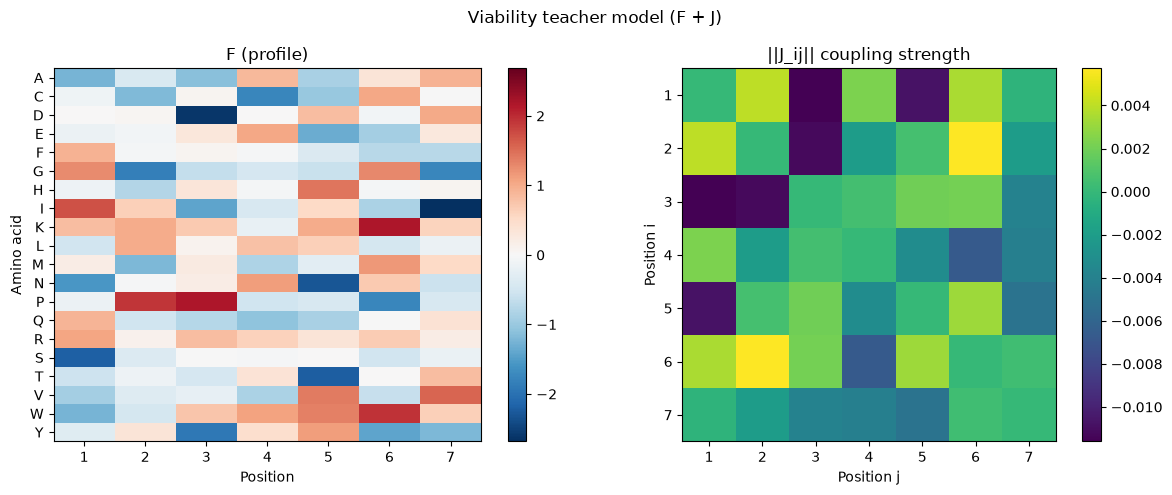

In [10]:
_ = plot_teacher_weights(F_viab, J_viab, title="Viability teacher model (F + J)")
plt.show()

## 3. Build the `Protocol`

`Protocol` wraps the whole simulation: `sequence` (identity, `(d0, 7)`, constant) and
`lambda0..lambda4` / `lambda0p,2p,3p` (abundance pools, all `(d0,)`, evolve each round).

In [9]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Initial library, colored by viability/selectivity score (function 2):

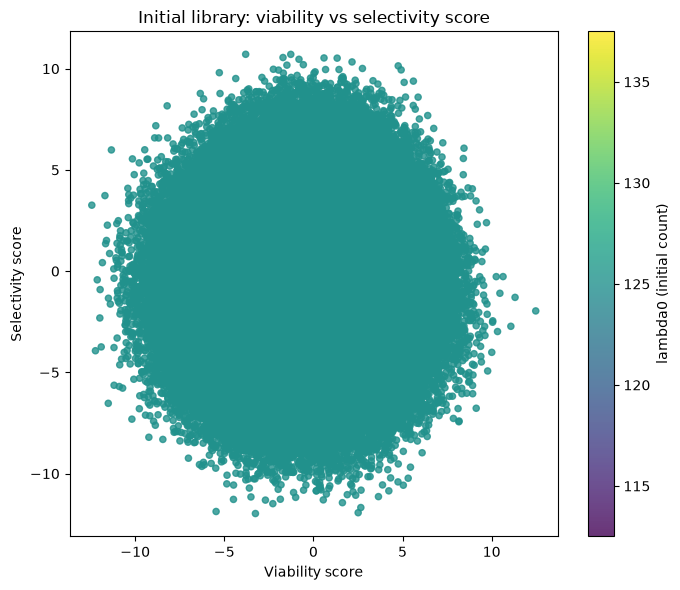

In [10]:
_ = plot_initial_library_scores(protocol)
plt.show()

## 4. Run one round of `loop_DE()`

In [11]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,137  non-zero=799997 / 800000
  lambda2    total=123,522,105,344  non-zero=9145 / 800000
  lambda3    total=43,054,669,824  non-zero=7981 / 800000
  lambda4    total=   100,001,952  non-zero=4731 / 800000
  lambda0p   total= 9,995,730,169  non-zero=799999 / 800000
  lambda2p   total= 9,684,555,197  non-zero=8119 / 800000
  lambda3p   total= 9,410,864,439  non-zero=6875 / 800000


Counts through viability + selectivity (function 3):

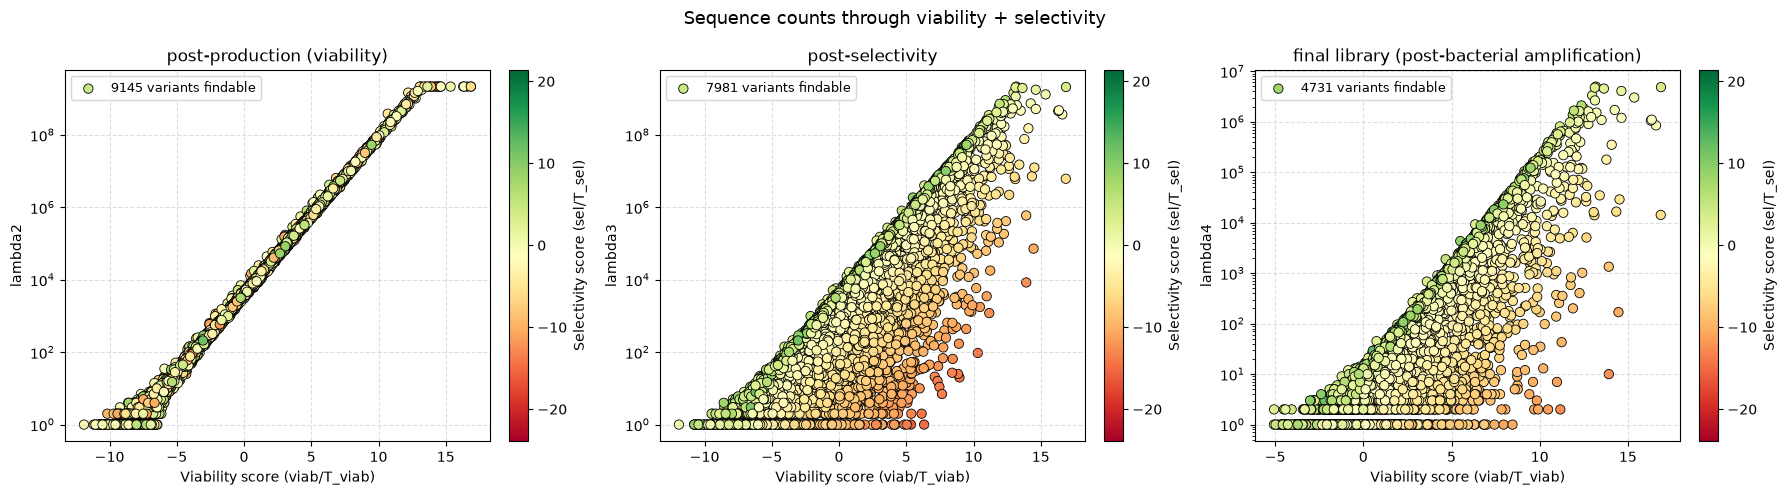

In [12]:
_ = plot_counts_after_selection(protocol)
plt.show()

All 8 lambdas of that same round on one plot (function 8):

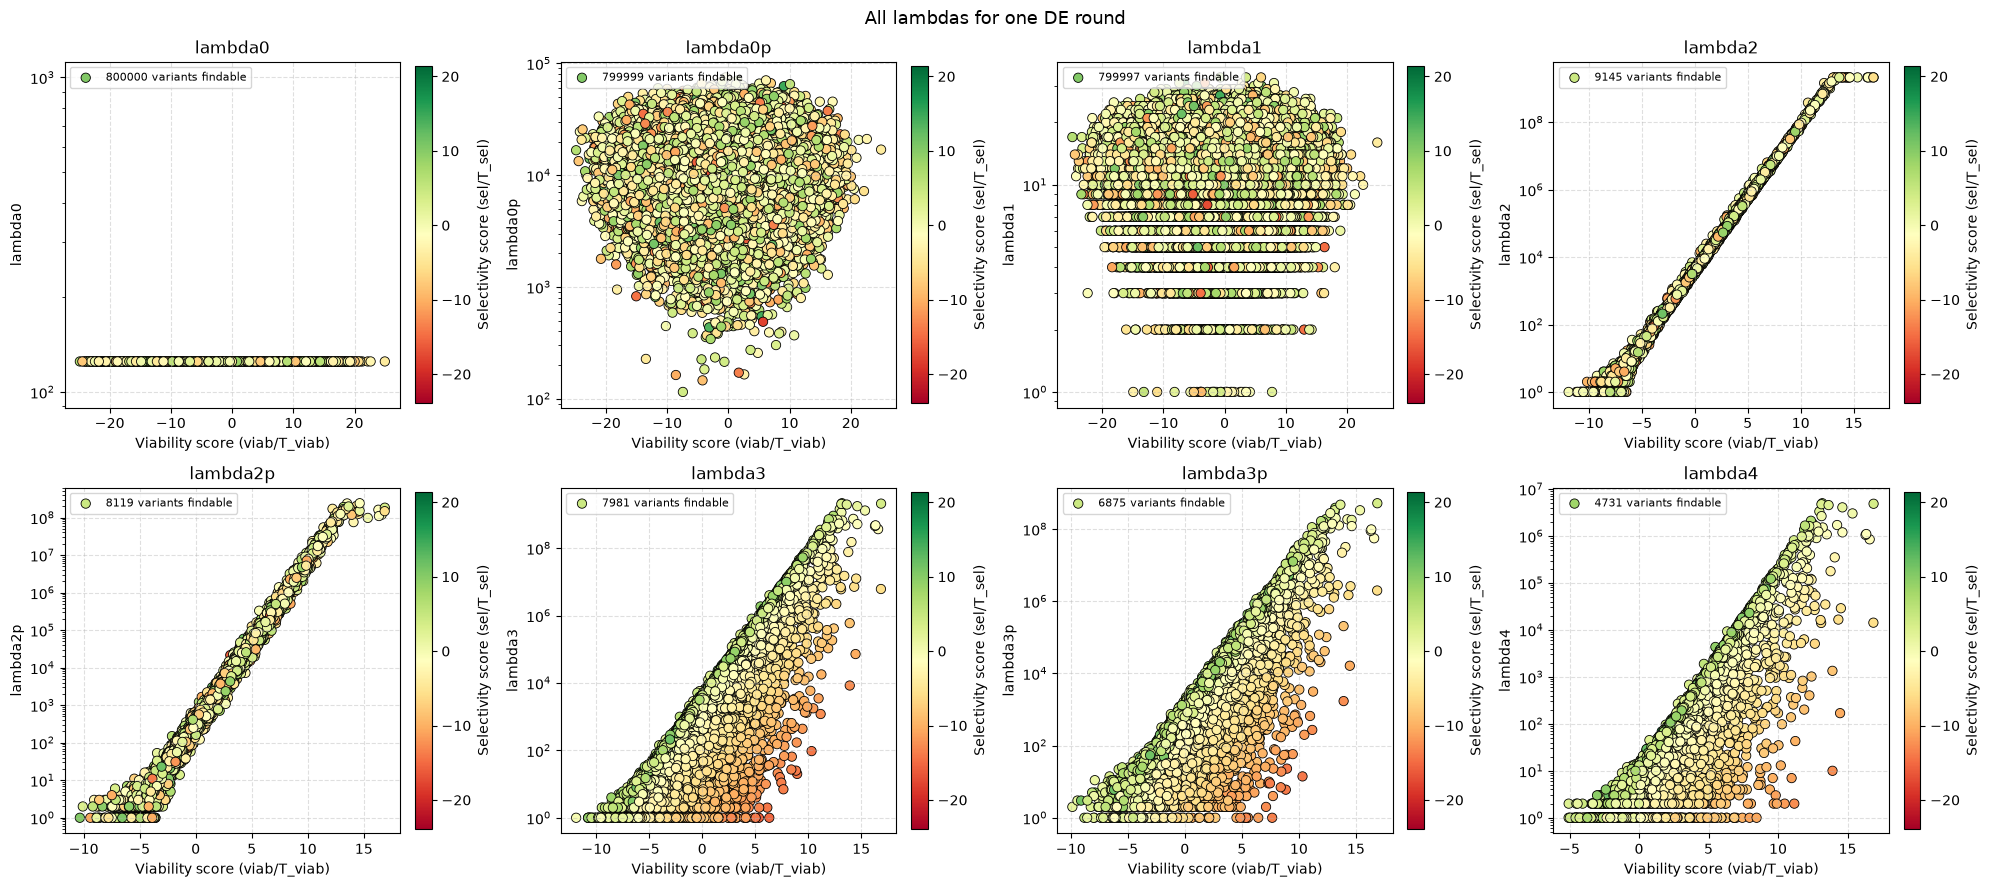

In [13]:
_ = plot_loop_lambdas(protocol, run_loop=False)  # reuse the round we just ran
plt.show()

## 5. Run several rounds with `N_loop_DE` and track library evolution

In [14]:
"""protocol_multi = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences, 
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, 
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)
plt.show()

print(f"N_loop_DE returned {len(rounds)} rounds")"""

'protocol_multi = ProtocolV2(\n    N0=100_000_000, N1=10_000_000, sequences=sequences, \n    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, \n    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,\n)\n\nfig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)\nplt.show()\n\nprint(f"N_loop_DE returned {len(rounds)} rounds")'

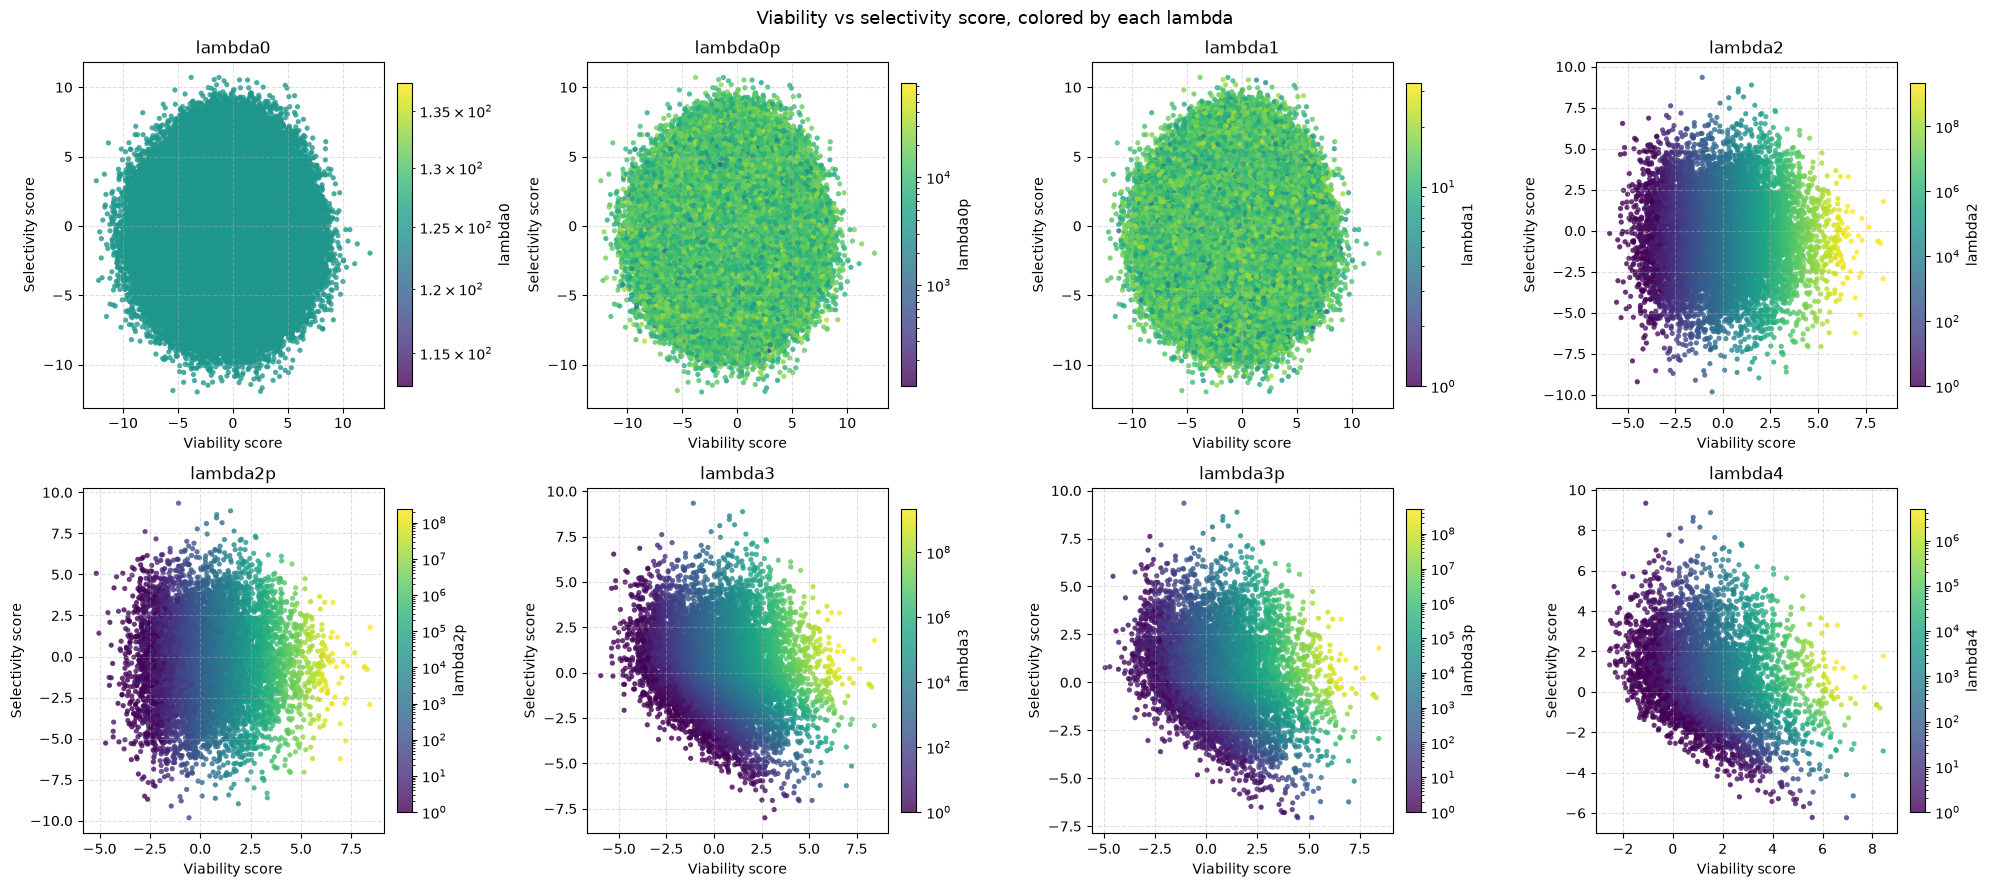

In [15]:
_ = plot_all_lambda_scores(protocol)
plt.show()

## Test 1 : Value of F, the factor of dilution

Whatever the value of D, a large part of sequences disappear in the NGS. Lets see how many sequences we have over some threshold.

In [16]:
threshold_values = [10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
lambdas          = [lambda0, lambda1, lambda2, lambda3, lambda4]
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]

number_of_seq_threshold(lambdas=lambdas, thresholds=threshold_values, names=names)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0,800000,800000,0,0,0,0
lambda1,638634,0,0,0,0,0
lambda2,8249,6983,5431,3688,2174,1069
lambda3,6742,5363,3899,2447,1389,647
lambda4,2982,1720,846,337,123,29


In [17]:
lambdaps         = [lambda0p, lambda2p, lambda3p]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]
number_of_seq_threshold(lambdas=lambdaps, thresholds=threshold_values, names=namesp)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0p,799999,799999,799737,479426,0,0
lambda2p,6827,5229,3504,1998,975,395
lambda3p,5863,4414,2931,1720,846,333


Relative proportions (`proportion_above_threshold` from `analysisV1.py`): how many sequences are abundant -- present above a given percentage of the pool total -- for the biological chain and the NGS reads separately.

In [18]:
pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,0,0,0,800000,800000,800000,800000,800000,800000,800000
lambda1,0,0,0,0,638634,799997,799997,799997,799997,799997,799997
lambda2,32,145,388,1003,2035,3541,5274,6853,8128,8895,9145
lambda3,29,123,337,844,1721,2942,4465,5858,7117,7981,7981
lambda4,29,123,337,846,1717,2921,4169,4731,4731,4731,4731


In [19]:
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds_p, names=names)

,> 0.0001%,> 8e-05%,> 6e-05%,> 5.5e-05%,> 5e-05%,> 4.5e-05%,> 4e-05%,> 2e-05%,> 1e-05%
lambda,,,,,,,,,
lambda0,800000,800000,800000,800000,800000,800000,800000,800000,800000
lambda1,638634,744223,788131,788131,795799,795799,798772,799963,799997
lambda2,2035,2180,2346,2406,2462,2531,2591,3043,3541
lambda3,1721,1822,1968,2011,2054,2109,2177,2524,2942
lambda4,1717,1806,1962,2004,2053,2103,2181,2520,2921


In [20]:
proportion_above_threshold(lambdas=lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,0,479643,799737,799999,799999,799999,799999,799999
lambda2p,33,147,398,989,2013,3519,5246,6827,8119,8119,8119
lambda3p,32,119,343,859,1745,2962,4453,5863,6875,6875,6875


The factor of dilution can help signicantly to get rid of variants that are not the optimal variants. The effect on noise should be analyse for further conclusion.

In [21]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=1000, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


In [22]:
new_bio_row, new_ngs_row = protocol.loop_DE()
new_lambda0, new_lambda1, new_lambda2, new_lambda3, new_lambda4 = new_bio_row
new_lambda0p, new_lambda2p, new_lambda3p = new_ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", new_lambda0), ("lambda1", new_lambda1), ("lambda2", new_lambda2),
                    ("lambda3", new_lambda3), ("lambda4", new_lambda4),
                    ("lambda0p", new_lambda0p), ("lambda2p", new_lambda2p), ("lambda3p", new_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
new_lambdaps         = [new_lambda0p, new_lambda2p, new_lambda3p]

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,137  non-zero=799997 / 800000
  lambda2    total=123,522,105,344  non-zero=9145 / 800000
  lambda3    total=43,054,669,824  non-zero=7981 / 800000
  lambda4    total=   100,001,952  non-zero=4731 / 800000
  lambda0p   total=10,002,709,303  non-zero=94093 / 800000
  lambda2p   total= 9,684,493,560  non-zero=5810 / 800000
  lambda3p   total= 9,410,178,926  non-zero=4270 / 800000


In [23]:
proportion_above_threshold(lambdas=new_lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,1,38841,89672,93812,94092,94093,94093,94093,94093
lambda2p,33,147,397,992,2023,3509,5204,5810,5810,5810,5810
lambda3p,32,119,342,858,1734,2984,4184,4270,4270,4270,4270


Visualizing which variants disappear as dilution increases: every variant found in `lambda3p` is plotted (x = viability score, y = selectivity score), once per `dilution_factor`, layered from red (weak dilution, most variants present) up to blue (strong dilution, drawn last/on top). A point that stays visibly red was lost once dilution increased; a point that ends up blue survived even the strongest dilution tested -- this lets us check directly whether attrition is uniform across score-space or concentrated on low-score (inefficient, lower-abundance) variants. Note the inclusion is only approximate (~97-99.8% overlap between consecutive levels), since each `dilution_factor` redraws independent randomness rather than sub-sampling the previous draw.

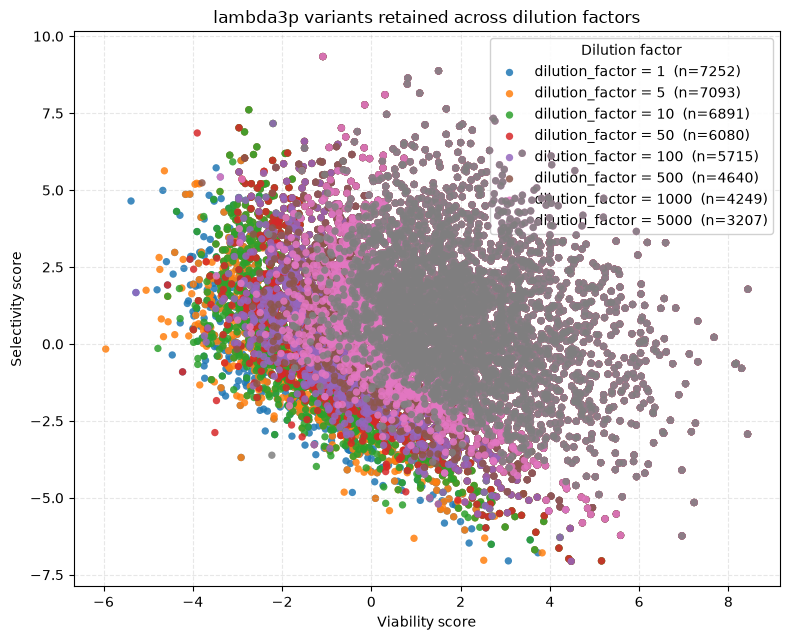

In [24]:
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

### Let's add some noise to see how dilution affects the results.

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,137  non-zero=799997 / 800000
  lambda2    total=463,616,802,816  non-zero=8661 / 800000
  lambda3    total=207,584,264,192  non-zero=7594 / 800000
  lambda4    total=   100,001,160  non-zero=3882 / 800000
  lambda0p   total= 9,995,730,169  non-zero=799999 / 800000
  lambda2p   total=10,070,689,780  non-zero=7145 / 800000
  lambda3p   total= 9,859,504,253  non-zero=6177 / 800000


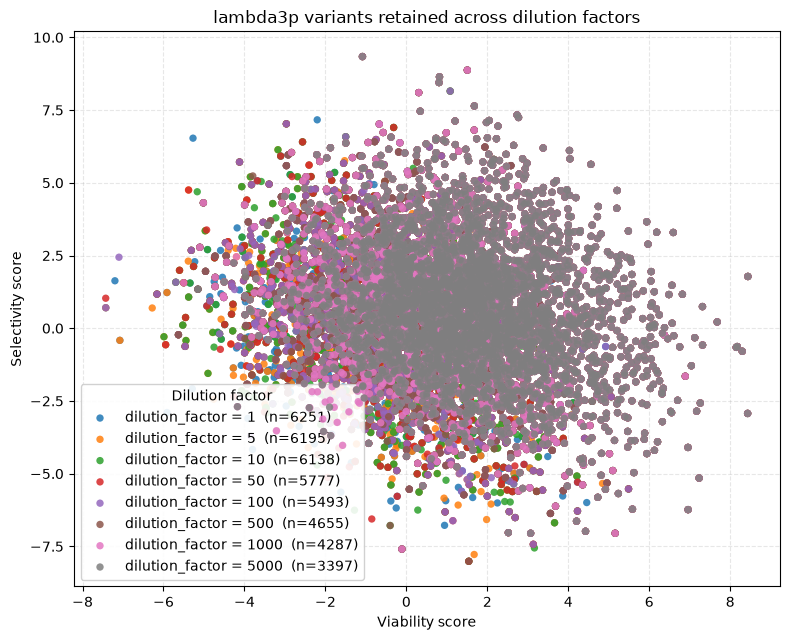

In [25]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

### What happens after multiple rounds (with and without noise)

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds: 100%|██████████| 3/3 [00:02<00:00,  1.16it/s]


  lambda0    total=   100,010,264  non-zero= 504 / 800000
  lambda1    total=    10,002,529  non-zero= 500 / 800000
  lambda2    total=305,362,337,792  non-zero= 277 / 800000
  lambda3    total=197,563,564,032  non-zero= 277 / 800000
  lambda4    total=   100,000,352  non-zero= 277 / 800000
  lambda0p   total= 9,440,100,291  non-zero= 500 / 800000
  lambda2p   total=10,293,913,762  non-zero= 277 / 800000
  lambda3p   total= 9,909,391,770  non-zero= 277 / 800000


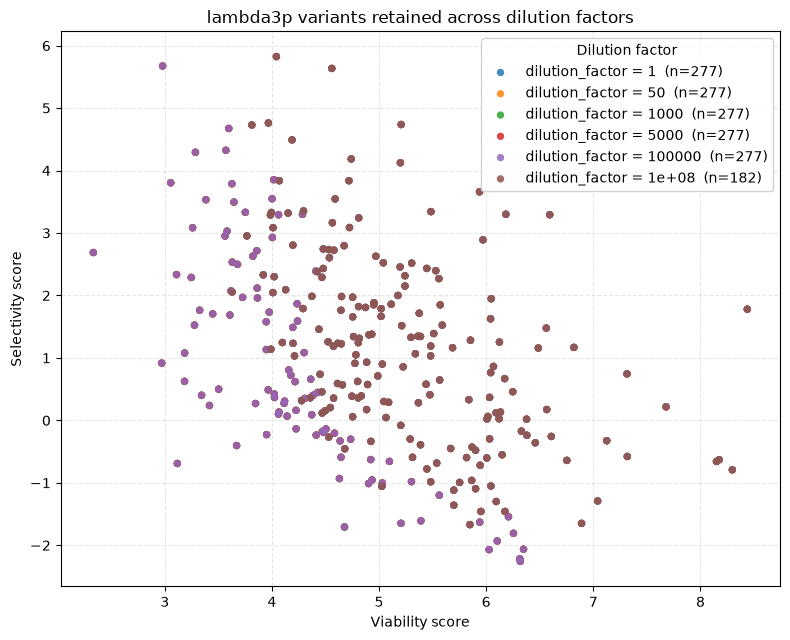

In [26]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
lambdas = protocol.N_loop_DE(3)
last_lambda0, last_lambda1, last_lambda2, last_lambda3, last_lambda4 = lambdas[-1][0]
last_lambda0p, last_lambda2p, last_lambda3p = lambdas[-1][1]

for label, arr in [("lambda0", last_lambda0), ("lambda1", last_lambda1), ("lambda2", last_lambda2),
                    ("lambda3", last_lambda3), ("lambda4", last_lambda4),
                    ("lambda0p", last_lambda0p), ("lambda2p", last_lambda2p), ("lambda3p", last_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()


In [27]:
proportion_above_threshold(lambdas=lambdas[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,47,140,247,395,482,500,504,504,504,504,504
lambda1,47,140,246,396,481,498,500,500,500,500,500
lambda2,0,161,215,266,277,277,277,277,277,277,277
lambda3,45,143,217,269,277,277,277,277,277,277,277
lambda4,45,143,217,269,277,277,277,277,277,277,277


protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds: 100%|██████████| 3/3 [00:02<00:00,  1.26it/s]


  lambda0    total=    99,997,752  non-zero= 503 / 800000
  lambda1    total=    10,006,281  non-zero= 463 / 800000
  lambda2    total=496,502,636,544  non-zero= 320 / 800000
  lambda3    total=358,369,067,008  non-zero= 319 / 800000
  lambda4    total=   100,007,888  non-zero= 315 / 800000
  lambda0p   total=10,003,688,149  non-zero= 461 / 800000
  lambda2p   total= 9,957,480,586  non-zero= 319 / 800000
  lambda3p   total=10,242,674,865  non-zero= 319 / 800000


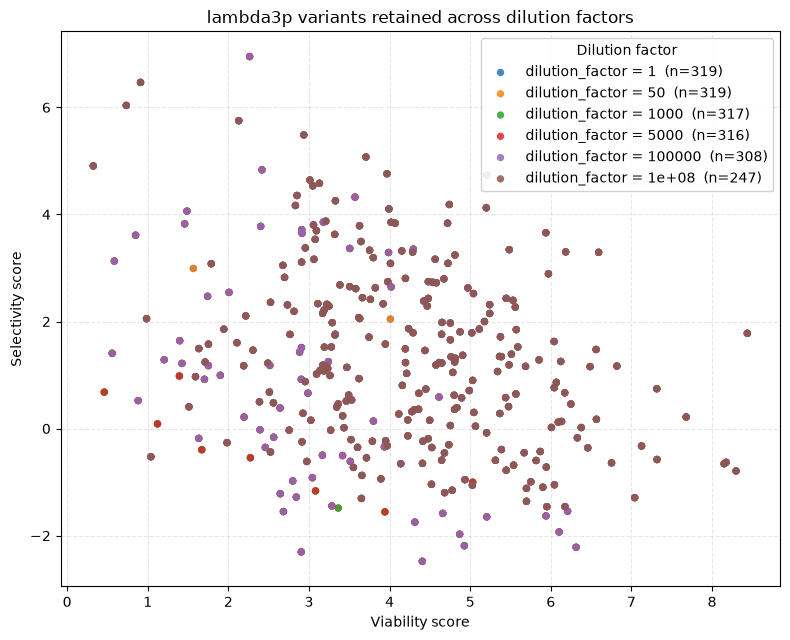

In [28]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
lambdas = protocol.N_loop_DE(3)
last_lambda0, last_lambda1, last_lambda2, last_lambda3, last_lambda4 = lambdas[-1][0]
last_lambda0p, last_lambda2p, last_lambda3p = lambdas[-1][1]

for label, arr in [("lambda0", last_lambda0), ("lambda1", last_lambda1), ("lambda2", last_lambda2),
                    ("lambda3", last_lambda3), ("lambda4", last_lambda4),
                    ("lambda0p", last_lambda0p), ("lambda2p", last_lambda2p), ("lambda3p", last_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

In [29]:
proportion_above_threshold(lambdas=lambdas[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,210,299,365,415,457,503,503,503,503,503
lambda1,0,210,300,367,416,449,463,463,463,463,463
lambda2,0,238,263,287,300,310,317,318,319,319,320
lambda3,0,213,258,283,296,307,315,317,319,319,319
lambda4,0,213,258,283,297,308,314,315,315,315,315


## 6. Weight recovery test (`RegressionV1.py`) : impact of initial diversity

`RegressionV1.fit_weights_potts` / `ridge_cv_mse_potts` implement standard **L2 (Ridge) regression**: the normal equations solved are `(X^T X + lambda*I) w = X^T y` -- Tikhonov/L2 regularization added to the diagonal (the bias column is excluded from the penalty), the same closed-form Ridge fit used in `First_modelization/Potts_regression.ipynb`.

`recover_weights_from_NGS(protocol, n_rounds=...)` uses ONLY the observable NGS reads (`lambda0p`, `lambda2p`, `lambda3p`) pooled across `n_rounds` of `N_loop_DE` -- never the internal `lambda0..lambda4` ground truth -- to fit `F_viab`/`J_viab` (viability step) and `F_sel`/`J_sel` (selectivity step), then cross-validates the ridge penalty per step.

**Scale note:** the main `protocol` above uses the full library (`sequences`, ~hundreds of thousands of variants). At that scale the 8541-feature Ridge fit (140 single-site + 8400 pairwise + 1 bias) is not tractable here: a single solve on an 8541x8541 system already takes several seconds, and the feature matrix itself would need tens of GB of memory once pooled over multiple rounds of observed reads. This test therefore uses a smaller library sized for the regression demo, not the full-scale one.

In [30]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 2000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

protocol_reg = ProtocolV2(
    N0=1_000_000, N1=500_000, dilution_factor=10, sequences=sequences_reg, D=100_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 138 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31.6228
Best lambda (selectivity) : 0.1000

n_obs_viab = 2000   n_obs_sel = 138
best lambda (viab) = 31.623   best lambda (sel) = 0.100

  r_viab_scores        : 0.5254
  r_sel_scores         : 0.5536
  r_viab_weights       : 0.7471
  r_sel_weights        : 0.6195
  precision_at_1pct    : 0.1500
  precision_at_10pct   : 0.4250


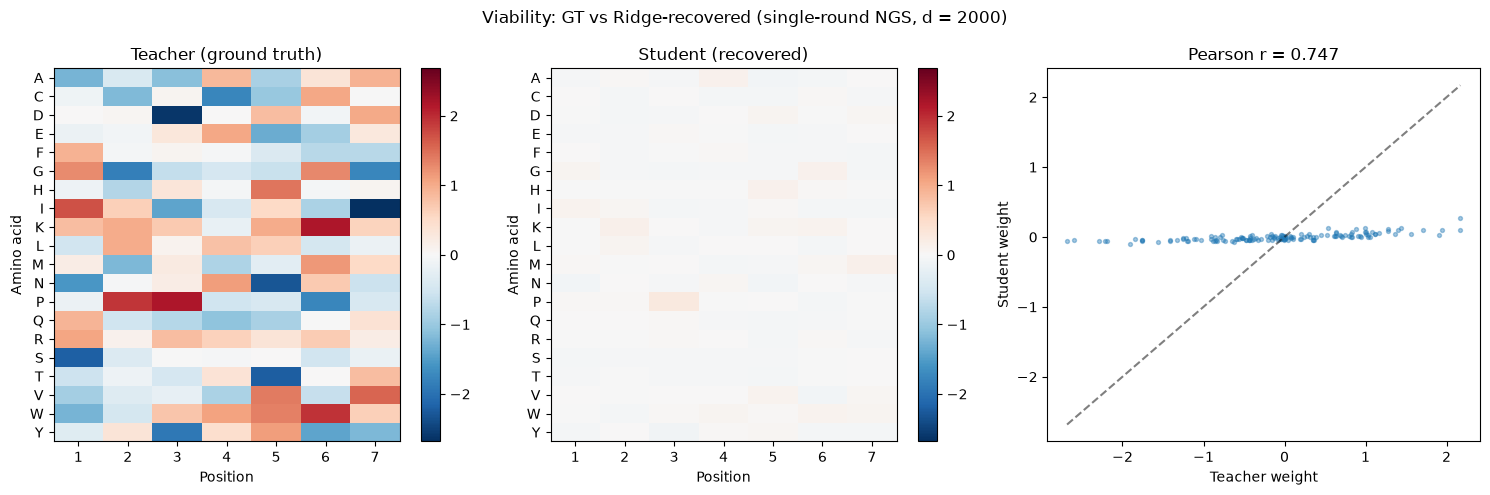

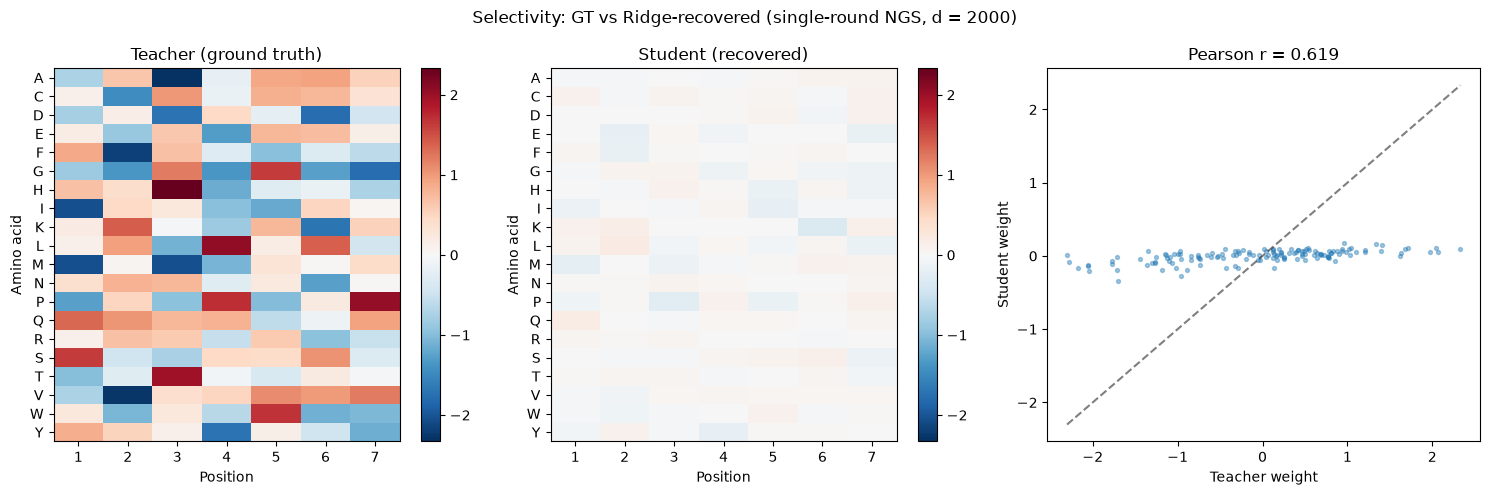

In [31]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title=f"Viability: GT vs Ridge-recovered (single-round NGS, d = {N_reg})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title=f"Selectivity: GT vs Ridge-recovered (single-round NGS, d = {N_reg})")

Very clearly, the vaibility and selectivity phases are not understand by the model here, two options, either the phases are not discriminatory enough, either the noise is too loud and the model cannot understand the underlying rules for variants efficiency

Very clearly, the vaibility and selectivity phases are not understand by the model here, two options, either the phases are not discriminatory enough, either the noise is too loud and the model cannot understand the underlying rules for variants efficiency

In [32]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 200000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

protocol_reg = ProtocolV2(
    N0=100_000_000, N1=1_000_000, dilution_factor=100, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

print("F_viab_hat = {F_viab_hat}, J_viab_hat = {J_viab_hat}, F_sel_hat = {F_sel_hat}, J_sel_hat = {J_sel_hat}")
print("starting evaluating recovery")

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.41s/it]


Viability   dataset: 198651 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 696 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31622.7766
Best lambda (selectivity) : 0.1000
F_viab_hat = {F_viab_hat}, J_viab_hat = {J_viab_hat}, F_sel_hat = {F_sel_hat}, J_sel_hat = {J_sel_hat}
starting evaluating recovery

n_obs_viab = 198651   n_obs_sel = 696
best lambda (viab) = 31622.777   best lambda (sel) = 0.100

  r_viab_scores        : 0.6279
  r_sel_scores         : 0.8506
  r_viab_weights       : 0.6682
  r_sel_weights        : 0.8947
  precision_at_1pct    : 0.2310
  precision_at_10pct   : 0.4113


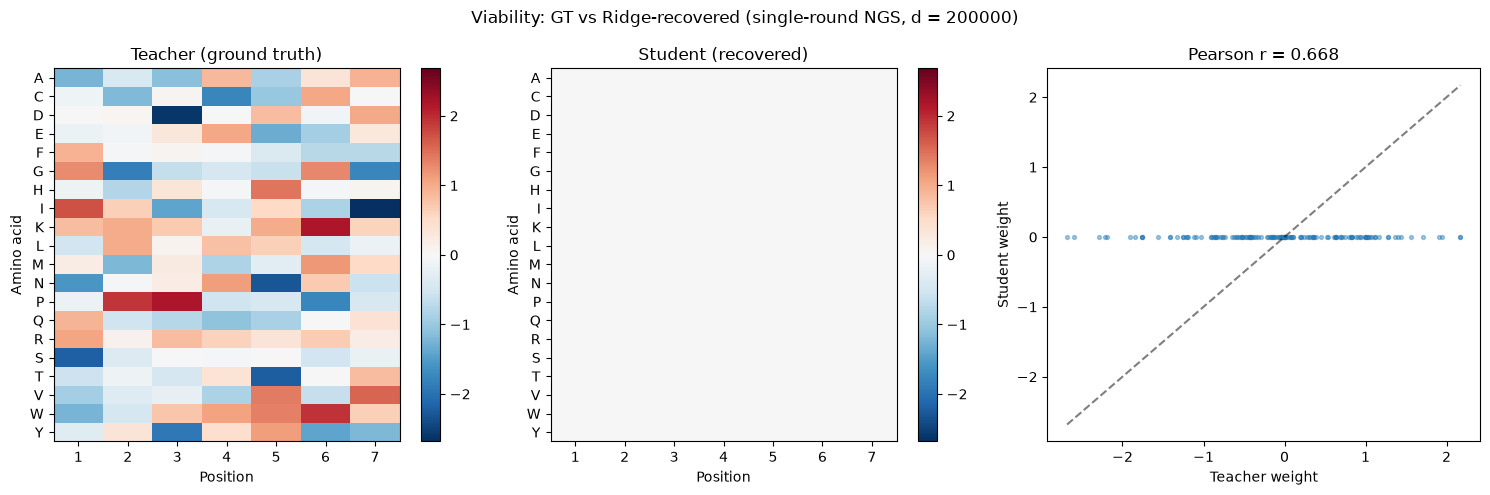

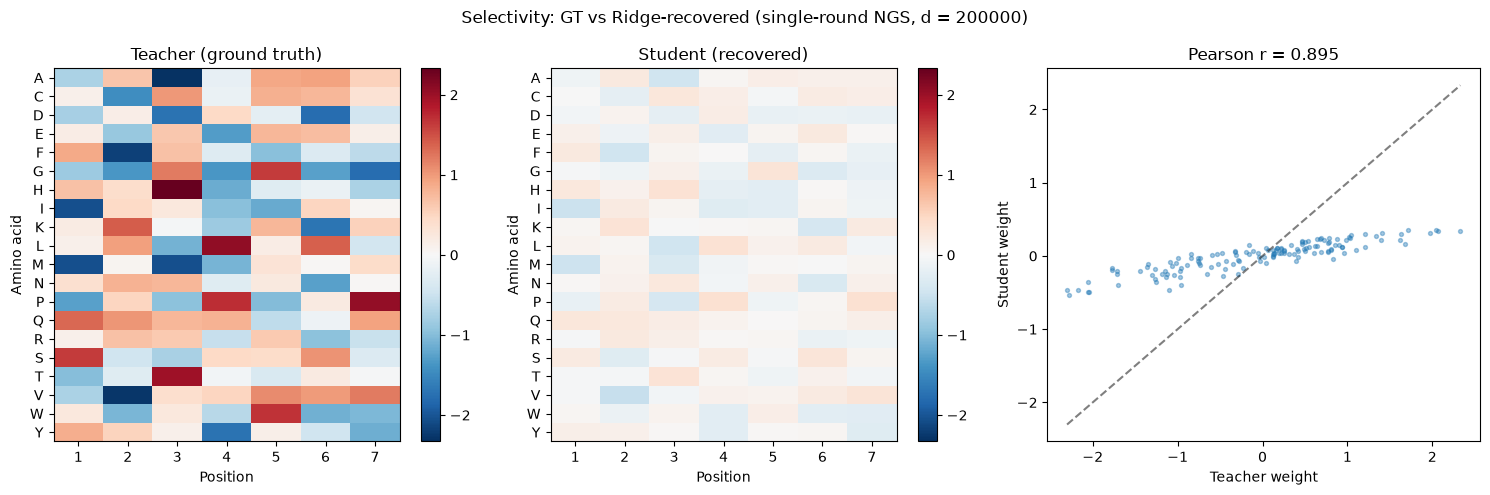

In [33]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title=f"Viability: GT vs Ridge-recovered (single-round NGS, d = {N_reg})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title=f"Selectivity: GT vs Ridge-recovered (single-round NGS, d = {N_reg})")

## 7. Weight recovery : impact of pressure for viability and selectivity phase

First only on Viability

In [34]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 2000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

####################################################################################
####################################################################################
new_T_viab = 10
new_T_sel  = 10
####################################################################################
####################################################################################

protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.09s/it]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 1.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 100.000   best lambda (sel) = 1.000

  r_viab_scores        : 0.5272
  r_sel_scores         : 0.8685
  r_viab_weights       : 0.6578
  r_sel_weights        : 0.9611
  precision_at_1pct    : 0.1500
  precision_at_10pct   : 0.3850


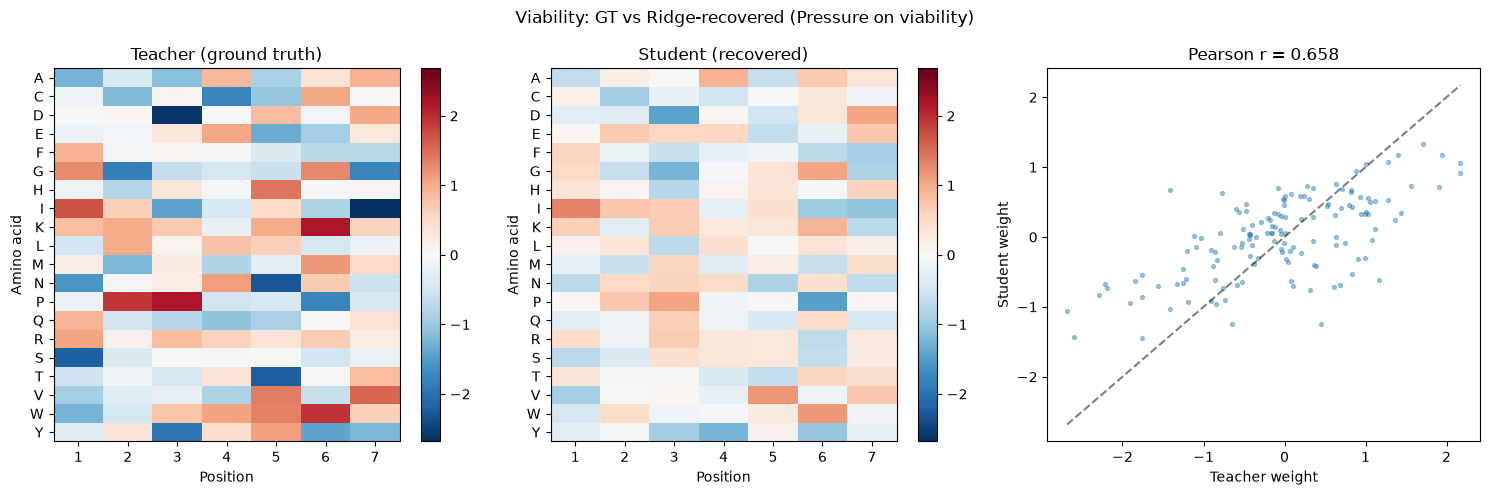

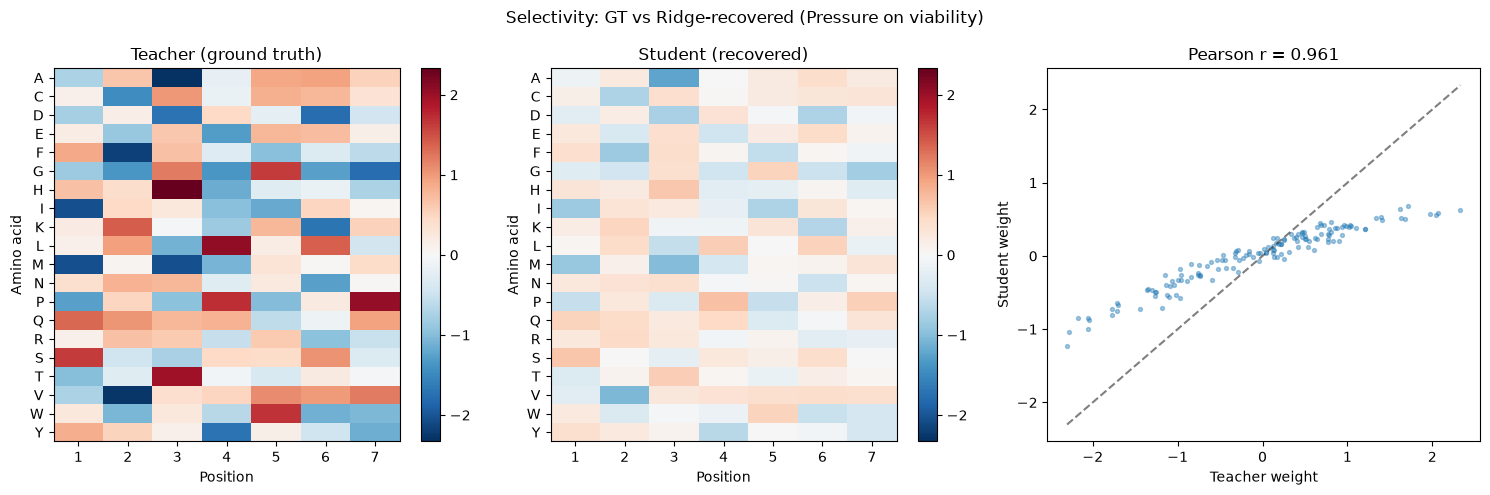

In [35]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on viability)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on viability)")

Then on selectivity

In [36]:
protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_sel=new_T_sel
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1423 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 0.1000
Best lambda (selectivity) : 100.0000

n_obs_viab = 2000   n_obs_sel = 1423
best lambda (viab) = 0.100   best lambda (sel) = 100.000

  r_viab_scores        : 0.9189
  r_sel_scores         : 0.4272
  r_viab_weights       : 0.9810
  r_sel_weights        : 0.5120
  precision_at_1pct    : 0.8000
  precision_at_10pct   : 0.8700


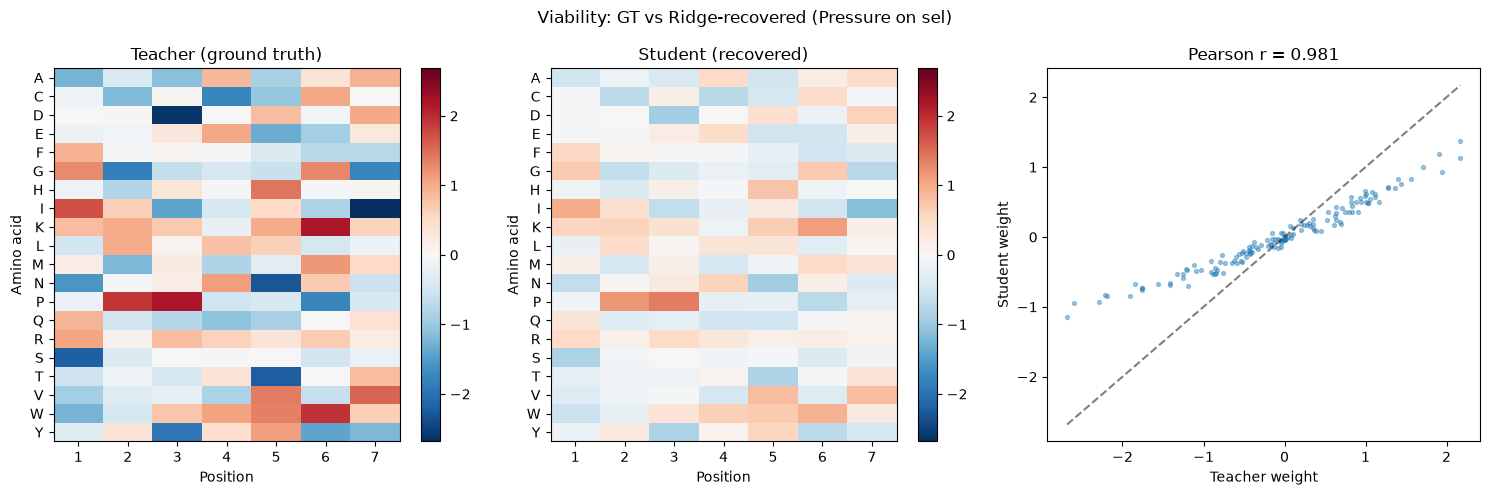

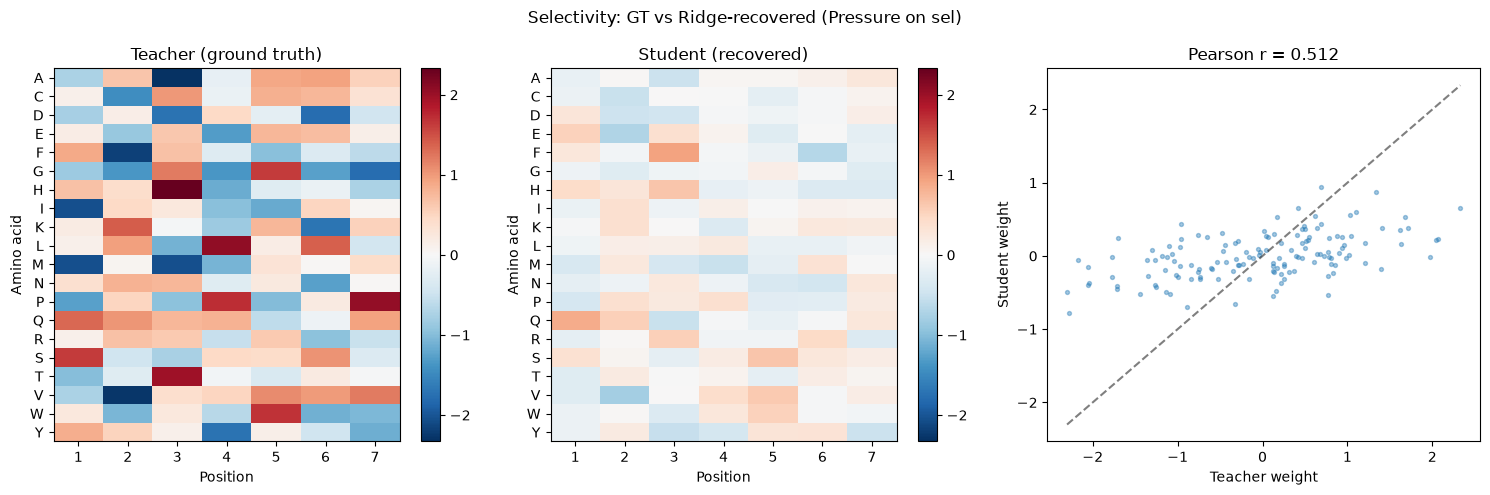

In [37]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on sel)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on sel)")

Finally on both

In [38]:
protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.28it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 100.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 100.000   best lambda (sel) = 100.000

  r_viab_scores        : 0.5272
  r_sel_scores         : 0.6500
  r_viab_weights       : 0.6578
  r_sel_weights        : 0.7808
  precision_at_1pct    : 0.2500
  precision_at_10pct   : 0.4850


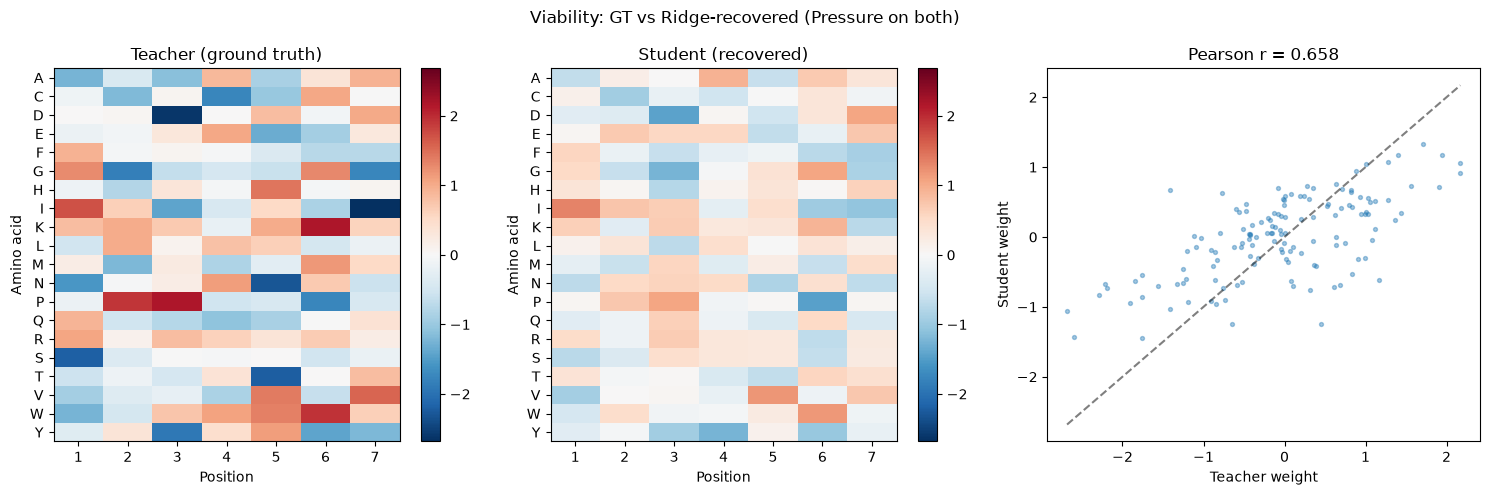

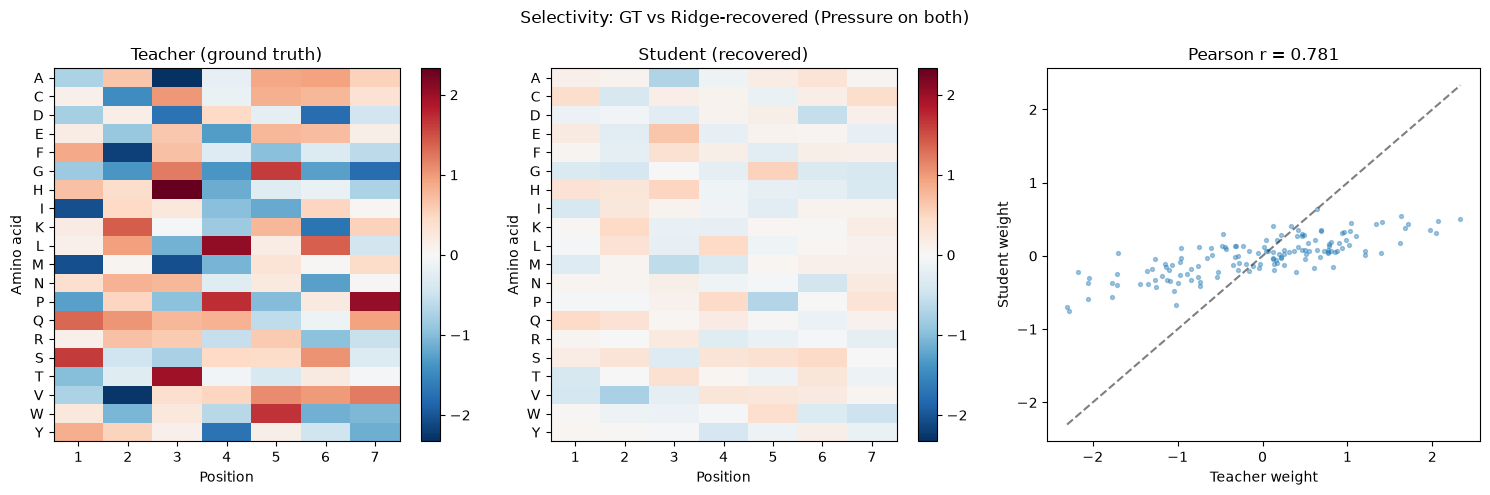

In [39]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on both)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on both)")

## 8. Weights recovery : impact of using parallel loop

In [11]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 10_000
N_split = 2
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

sequences_reg_split = jnp.split(sequences_reg, N_split)
F_viab_hat_list, J_viab_hat_list, F_sel_hat_list, J_sel_hat_list, info_list = [], [], [], [], []

for i in range(N_split):
    protocol_reg = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_split[i], D=100_000_000,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1,
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg, n_rounds=1, k_folds=3,
    )
    F_viab_hat_list.append(F_viab_hat)
    J_viab_hat_list.append(J_viab_hat)
    F_sel_hat_list.append(F_sel_hat)
    J_sel_hat_list.append(J_sel_hat)
    info_list.append(info)

F_viab_hat_list = jnp.array(F_viab_hat_list)
J_viab_hat_list = jnp.array(J_viab_hat_list)
F_sel_hat_list  = jnp.array(F_sel_hat_list)
J_sel_hat_list  = jnp.array(J_sel_hat_list)

F_viab_hat_avg = jnp.mean(F_viab_hat_list, axis=0)
J_viab_hat_avg = jnp.mean(J_viab_hat_list, axis=0)
F_sel_hat_avg  = jnp.mean(F_sel_hat_list, axis=0)
J_sel_hat_avg  = jnp.mean(J_sel_hat_list, axis=0)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat_avg, J_viab_hat_avg, F_sel_hat_avg, J_sel_hat_avg)

for i in range(N_split):
    print()
    print(f"n_obs_viab = {info_list[i]['n_obs_viab']}   n_obs_sel = {info_list[i]['n_obs_sel']}")
    print(f"best lambda (viab) = {info_list[i]['lam_viab']:.3f}   best lambda (sel) = {info_list[i]['lam_sel']:.3f}")

print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]


Viability   dataset: 5000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 2775 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31.6228
Best lambda (selectivity) : 10.0000
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


Viability   dataset: 5000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 2813 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31.6228
Best lambda (selectivity) : 10.0000

n_obs_viab = 5000   n_obs_sel = 2775
best lambda (viab) = 31.623   best lambda (sel) = 10.000

n_obs_viab = 5000   n_obs_sel = 2813
best lambda (viab) = 31.623   best lambda (sel) = 10.000

  r_viab_scores        : 0.9565
  r_sel_scores         : 0.9082
  r_viab_weights       : 0.9802
  r_sel_weights        : 0.9410
  precision_at_1pct    : 0.5200
  precision_at_10pct   : 0.6760


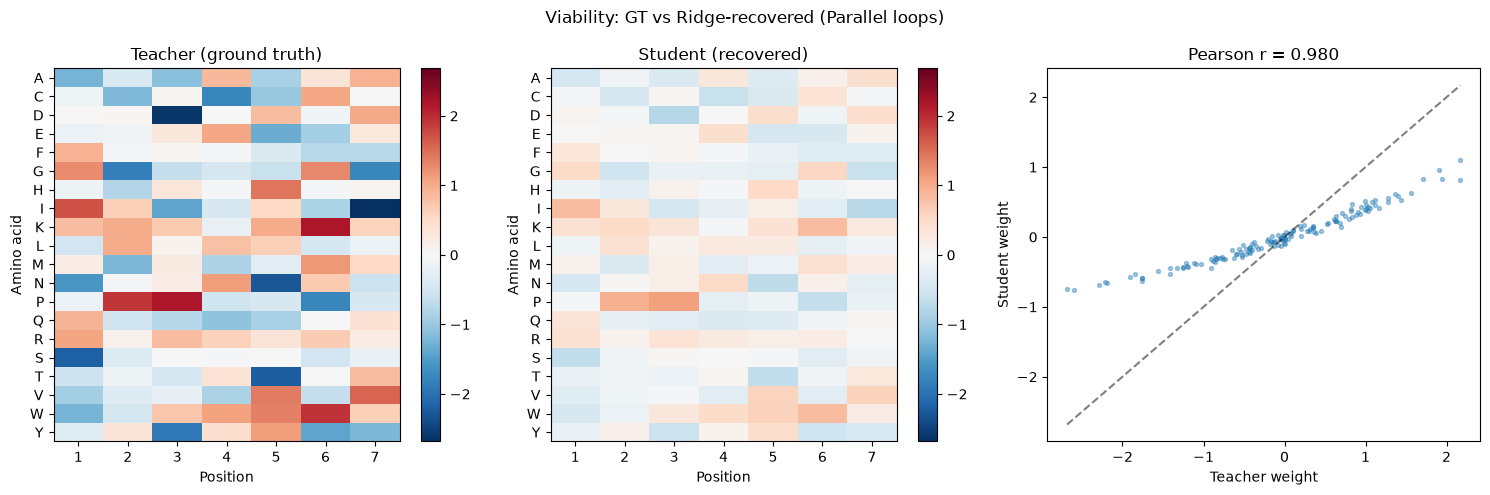

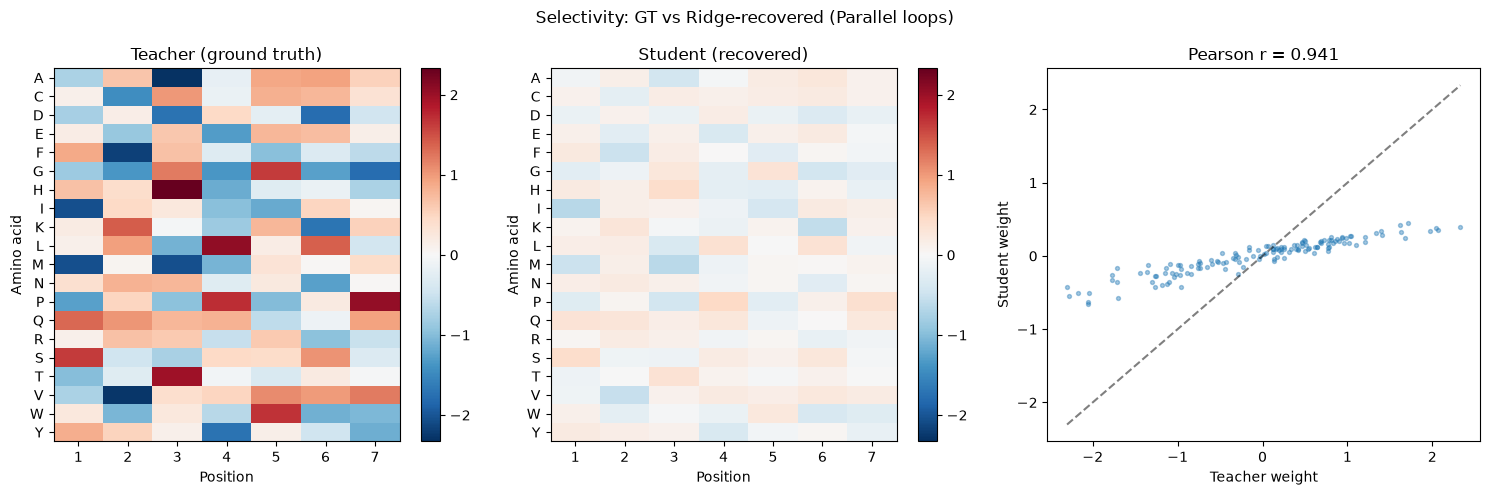

In [12]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_avg, title="Viability: GT vs Ridge-recovered (Parallel loops)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_avg, title="Selectivity: GT vs Ridge-recovered (Parallel loops)")

## 9. Weights recovery : Impact of the NGS's depth

In [ ]:
D_values = [1e3, 1e5, 1e7, 1e9, 1e11, 1e13]

for D in D_values:
    print(D)
    protocol_reg = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=D,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg, n_rounds=1, k_folds=3,
    )

    results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
    print()
    print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
    print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
    print()
    for key, val in results.items():
        print(f'  {key:20s} : {val:.4f}')
    _ = plot_teacher_vs_student(F_viab, F_viab_hat, title=f"Viability: GT vs Ridge-recovered (D = {D})")
    _ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (D = {D})")

## 10. Weights recovery : Impact of noise

We will do this part after finding which of the previous parameters are optimals.

# NEXT PART : Variants recovery

The question here is which value for the parameters is optimal to keep the best theoretical variants.